In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

2026-04-30 00:10:44.077370: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [41]:
# generate dataset
N=10000
A = np.random.uniform(0.5,1.5,size=(N,1))
w = np.random.uniform(0.5,2,size=(N,1))
phi = np.random.uniform(0,2*np.pi,size=(N,1))
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [42]:
# generate noisy data
sigma = 0.2
err = np.random.normal(loc=0, scale=sigma, size=curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

Plot examples showing the clean and noisy curve.

Text(0.5, 1.0, 'Noisy Signals')

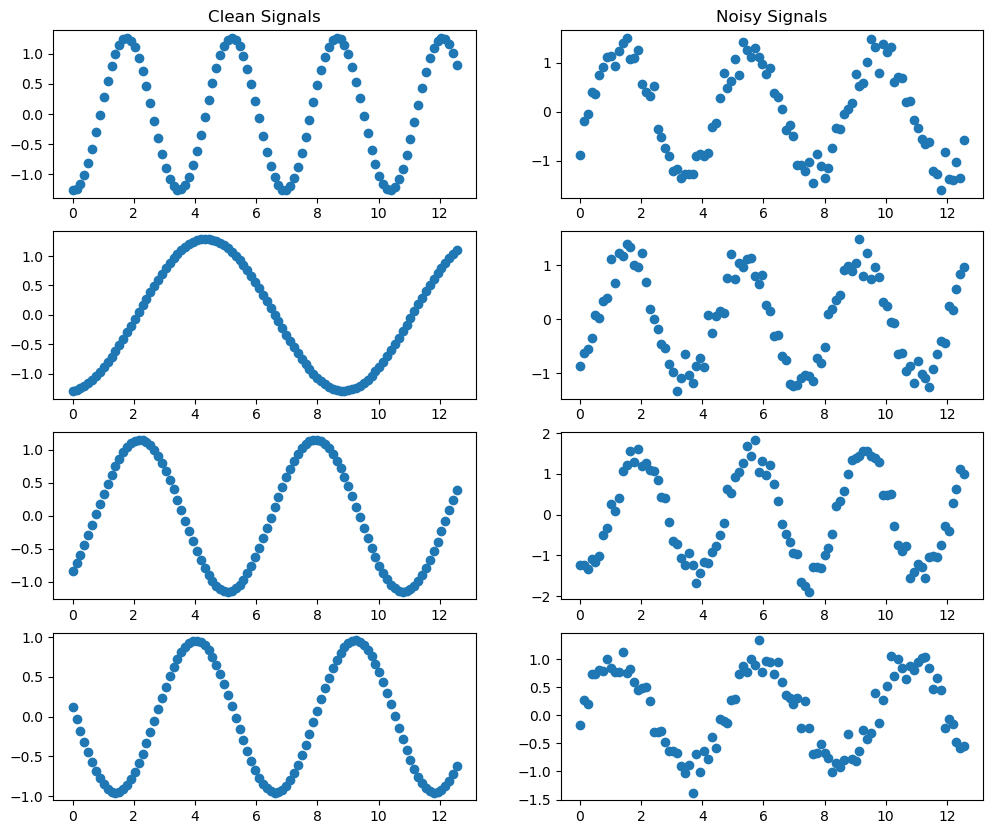

In [44]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes[0,0].scatter(t, curve[3])
axes[0,1].scatter(t, noisy_curve[3])

axes[1,0].scatter(t, curve[489])
axes[1,1].scatter(t, noisy_curve[489])

axes[2,0].scatter(t, curve[1864])
axes[2,1].scatter(t, noisy_curve[1864])

axes[3,0].scatter(t, curve[9999])
axes[3,1].scatter(t, noisy_curve[9999])

axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
#need to figure out how to label axes: all at once or just one set?

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [75]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(N) #this will shuffle through different indices
training_size = int(N*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [45]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,192 (4.93 MB)

 Trainable params: 1,292,192 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [ ]:
history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Plot the training and validation loss curves.

In [ ]:
# plot loss curves

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [ ]:
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) # Returns shape (4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

In [ ]:
# Plot clean / noisy / reconstructed for each example